# 05 — Mass-filtered ion imaging from raw FPD data

This notebook combines:

- spectrum calibration
- peak assignment
- automatic bin creation
- raw event image filtering

The result is a set of isotope/mass-filtered ion images.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum
from pymagsims.raw_image import SIMSRawImage
from pymagsims.isotopes import load_builtin_isotopes
from pymagsims.plotting import plot_ion_image_grid

DATA = Path("../data")
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")
raw = SIMSRawImage.from_fpd_raw(DATA / "FPD_image2.raw")
isotopes = load_builtin_isotopes()

## Detect and assign peaks

In [2]:
assignments = spec.assign_peaks(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
)

bins = spec.create_bins_from_assignments(
    assignments,
    width=0.3,
)

display(bins.head(20))

,label,element,isotope,center_mass,exact_mass,mass_error,mass_min,mass_max,integrated_intensity,max_intensity,n_points
0,12C,C,12C,12.142001,12.000000,0.142001,11.917001,12.367001,8839.0,600.0,65
1,13C,C,13C,13.196964,13.003355,0.193609,12.971964,13.421964,4016.0,254.0,62
2,57Fe,Fe,57Fe,56.830359,56.935393,-0.193354,56.517039,57.143679,66323.0,4005.0,43
3,63Cu,Cu,63Cu,62.868605,62.929598,-0.184762,62.519836,63.217374,289188.0,16600.0,45
4,64Zn,Zn,64Zn,63.831396,63.929142,-0.191271,63.512871,64.149922,87387.0,4989.0,41
5,65Cu,Cu,65Cu,64.911448,64.927790,-0.157796,64.544994,65.277902,130337.0,6953.0,47
6,66Zn,Zn,66Zn,65.952866,65.926034,-0.115737,65.585297,66.320435,48054.0,2517.0,47
7,69Ga,Ga,69Ga,68.939866,68.925574,-0.123333,68.577241,69.302492,1917634.0,99392.0,44
8,71Ga,Ga,71Ga,70.986594,70.924703,0.012611,70.712314,71.260875,9311.0,396.0,33


## Create mass-filtered images

In [3]:
images = raw.images_from_bins(
    spectrum=spec,
    bins=bins.head(8),
    include_total=True,
)

print(images.keys())

dict_keys(['Total', '12C', '13C', '57Fe', '63Cu', '64Zn', '65Cu', '66Zn', '69Ga'])


## Plot all ion images

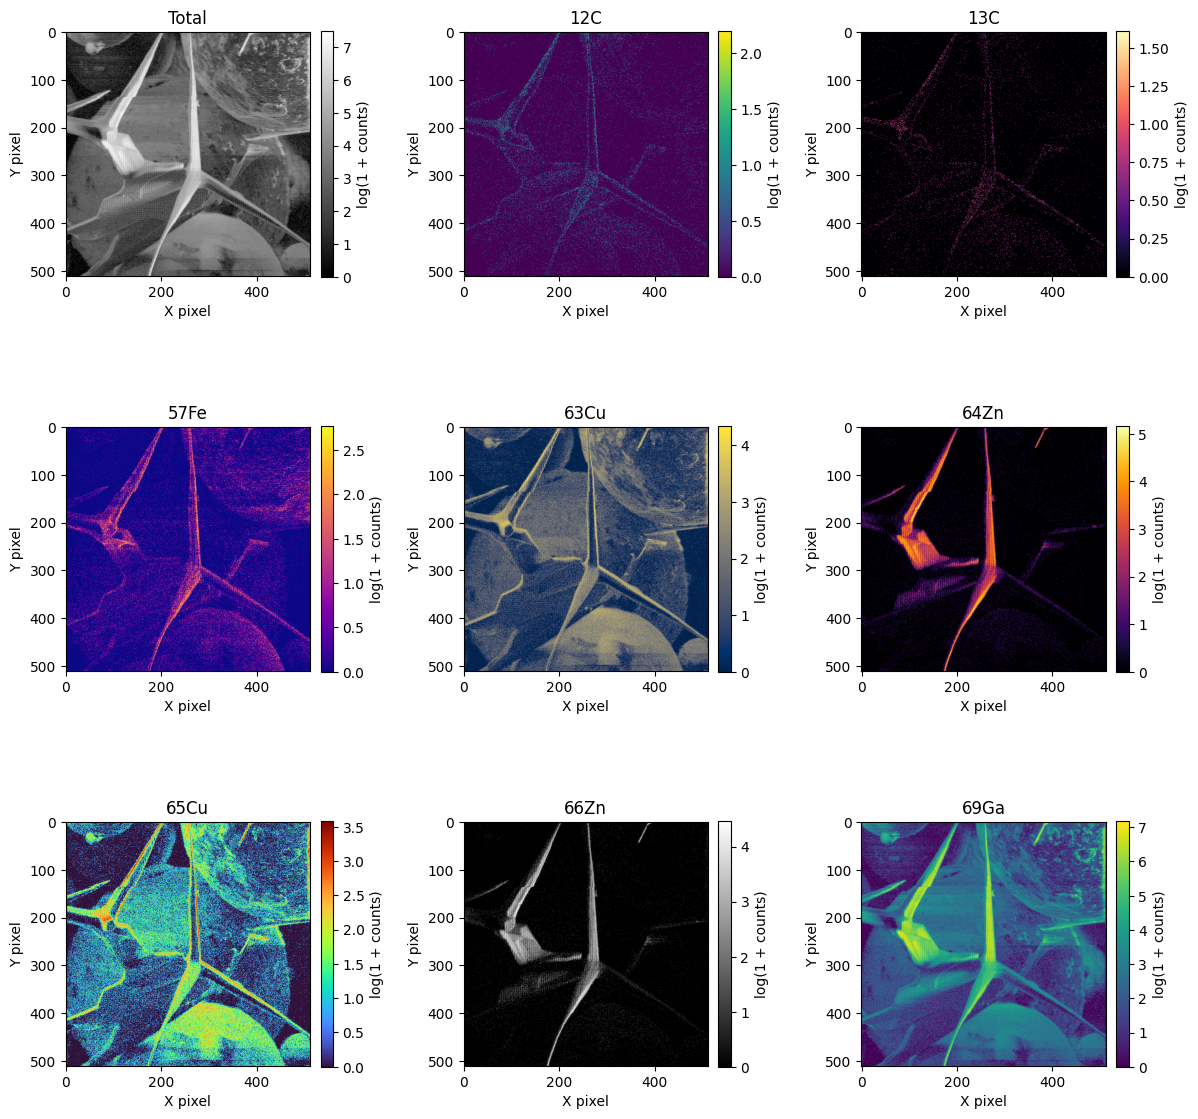

In [4]:
fig, axes = plot_ion_image_grid(
    images,
    log=True,
    ncols=3,
    cmaps=["gray", "viridis", "magma", "plasma", "cividis", "inferno", "turbo"],
)